In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt


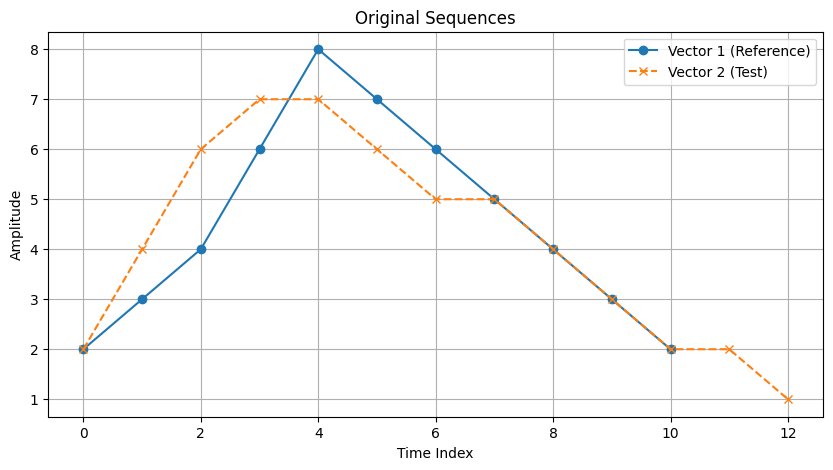

In [2]:
# Given Data
vector1 = np.array([2, 3, 4, 6, 8, 7, 6, 5, 4, 3, 2])   # Reference sequence
vector2 = np.array([2, 4, 6, 7, 7, 6, 5, 5, 4, 3, 2, 2, 1])  # Test sequence

# Create time axes
t1 = np.arange(len(vector1))
t2 = np.arange(len(vector2))

# Plot both vectors
plt.figure(figsize=(10,5))
plt.plot(t1, vector1, 'o-', label='Vector 1 (Reference)')
plt.plot(t2, vector2, 'x--', label='Vector 2 (Test)')
plt.title('Original Sequences')
plt.xlabel('Time Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


In [3]:
def dtw(x, y):
    n, m = len(x), len(y)
    cost = np.zeros((n, m))

    # Compute local distance (absolute difference)
    for i in range(n):
        for j in range(m):
            cost[i, j] = abs(x[i] - y[j])

    # Initialize accumulated cost matrix
    acc_cost = np.zeros((n, m))
    acc_cost[0, 0] = cost[0, 0]

    # Initialize first row and column
    for i in range(1, n):
        acc_cost[i, 0] = cost[i, 0] + acc_cost[i-1, 0]
    for j in range(1, m):
        acc_cost[0, j] = cost[0, j] + acc_cost[0, j-1]

    # Fill the accumulated cost matrix
    for i in range(1, n):
        for j in range(1, m):
            acc_cost[i, j] = cost[i, j] + min(
                acc_cost[i-1, j],    # insertion
                acc_cost[i, j-1],    # deletion
                acc_cost[i-1, j-1]   # match
            )

    return cost, acc_cost


In [4]:
# Compute cost and accumulated cost matrices
cost_matrix, acc_cost_matrix = dtw(vector1, vector2)

# Display the accumulated cost matrix
print("Accumulated Cost Matrix:\n")
print(np.round(acc_cost_matrix, 2))


Accumulated Cost Matrix:

[[ 0.  2.  6. 11. 16. 20. 23. 26. 28. 29. 29. 29. 30.]
 [ 1.  1.  4.  8. 12. 15. 17. 19. 20. 20. 21. 22. 24.]
 [ 3.  1.  3.  6.  9. 11. 12. 13. 13. 14. 16. 18. 21.]
 [ 7.  3.  1.  2.  3.  3.  4.  5.  7. 10. 14. 18. 23.]
 [13.  7.  3.  2.  3.  5.  6.  7.  9. 12. 16. 20. 25.]
 [18. 10.  4.  2.  2.  3.  5.  7. 10. 13. 17. 21. 26.]
 [22. 12.  4.  3.  3.  2.  3.  4.  6.  9. 13. 17. 22.]
 [25. 13.  5.  5.  5.  3.  2.  2.  3.  5.  8. 11. 15.]
 [27. 13.  7.  8.  8.  5.  3.  3.  2.  3.  5.  7. 10.]
 [28. 14. 10. 11. 12.  8.  5.  5.  3.  2.  3.  4.  6.]
 [28. 16. 14. 15. 16. 12.  8.  8.  5.  3.  2.  2.  3.]]


In [5]:
# Trace back from bottom-right to top-left
i, j = np.array(acc_cost_matrix.shape) - 1
path = [(i, j)]

while i > 0 or j > 0:
    if i == 0:
        j -= 1
    elif j == 0:
        i -= 1
    else:
        # Choose direction with minimum accumulated cost
        direction = np.argmin([
            acc_cost_matrix[i-1, j],    # up
            acc_cost_matrix[i, j-1],    # left
            acc_cost_matrix[i-1, j-1]   # diagonal
        ])
        if direction == 0:
            i -= 1
        elif direction == 1:
            j -= 1
        else:
            i -= 1
            j -= 1
    path.append((i, j))

path = path[::-1]  # reverse path to start from (0,0)
path = np.array(path)


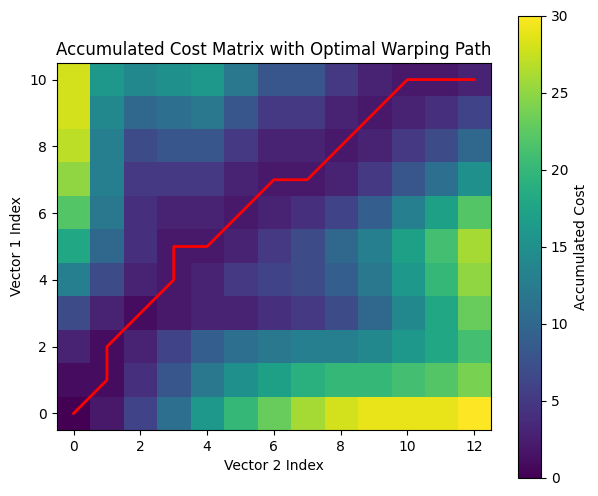

In [6]:
plt.figure(figsize=(7,6))
plt.imshow(acc_cost_matrix, origin='lower', cmap='viridis', interpolation='nearest')
plt.plot(path[:,1], path[:,0], 'r', linewidth=2)
plt.title('Accumulated Cost Matrix with Optimal Warping Path')
plt.xlabel('Vector 2 Index')
plt.ylabel('Vector 1 Index')
plt.colorbar(label='Accumulated Cost')
plt.show()


In [7]:
# DTW distance is the final value in the accumulated cost matrix
dtw_distance = acc_cost_matrix[-1, -1]
print(f"DTW Distance between the two sequences = {dtw_distance:.3f}")


DTW Distance between the two sequences = 3.000


### Inference:
Dynamic Time Warping (DTW) aligns two sequences by **non-linearly warping the time axis** to minimize the total alignment cost.

**Observations:**
- The warping path shows how the two vectors are matched in a **non-linear** manner.
- Some regions are stretched or compressed to align similar patterns.
- The final **DTW distance = {dtw_distance:.3f}**, which quantifies their similarity.
  - A **smaller DTW distance** indicates greater similarity.
  - A **larger DTW distance** implies more distortion is needed to align the sequences.

**Conclusion:**
DTW effectively handles sequences that differ in length or speed.
It aligns temporally distorted data (like speech or time series) by optimally mapping similar parts even when they occur at different times.
